# Post analysis

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import networkx as nx

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import igraph as ig
import leidenalg as la
from sqlalchemy.dialects.mssql.information_schema import columns

from social_graph.pipeline import *
from social_graph.metrics import *
from social_graph.describe import compare_persona_across_simulations

In [2]:
conn3 = sqlite3.connect("data/exp_set_1/database_server_3.db")
conn4 = sqlite3.connect("data/exp_set_1/database_server_4.db")
conn5 = sqlite3.connect("data/exp_set_1/database_server_5.db")

connb1 = sqlite3.connect("data/exp_set_1/database_server_b1.db")
connb2 = sqlite3.connect("data/exp_set_1/database_server_b2.db")
connb3 = sqlite3.connect("data/exp_set_1/database_server_b3.db")

In [3]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism', 'age', 'profession']

Running Simulation_3...

Data loading ...

Number of users: 1000
Total actions: 16424
Follow actions: 12317
Unfollow actions: 4107
Number of rounds: 61
Number of posts: 140111

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 25)

Searching best number of persona ...

k=2 silhouette=0.0816
k=3 silhouette=0.0961
k=4 silhouette=0.1382
k=5 silhouette=0.0972
k=6 silhouette=0.1022
k=7 silhouette=0.1138
k=8 silhouette=0.1054
k=9 silhouette=0.1170


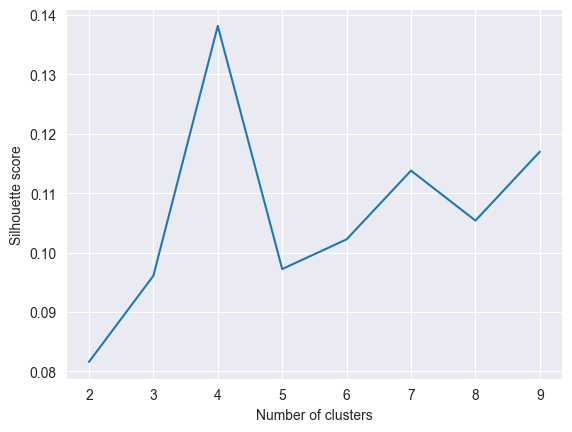


Done!
persona
Persona_3    257
Persona_4    255
Persona_2    248
Persona_1    240
Name: count, dtype: int64


,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level,persona
1,2,consistent/cautious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,young,Skilled_Trades,female,democrat,master,Persona_2
2,3,inventive/curious,efficient/organized,outgoing/energetic,friendly/compassionate,sensitive/nervous,old,Skilled_Trades,male,democrat,master,Persona_3
3,4,inventive/curious,extravagant/careless,outgoing/energetic,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,master,Persona_4
4,5,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,resilient/confident,old,Security,male,democrat,master,Persona_2
5,6,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,old,Science_Academia,male,democrat,master,Persona_3
...,...,...,...,...,...,...,...,...,...,...,...,...
996,997,inventive/curious,efficient/organized,solitary/reserved,critical/judgmental,sensitive/nervous,young,Transport,male,democrat,master,Persona_4
997,998,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,resilient/confident,middle,Security,male,democrat,master,Persona_2
998,999,inventive/curious,extravagant/careless,outgoing/energetic,critical/judgmental,resilient/confident,young,Agriculture,male,democrat,master,Persona_1
999,1000,inventive/curious,efficient/organized,outgoing/energetic,friendly/compassionate,resilient/confident,middle,Science_Academia,male,democrat,master,Persona_1


In [11]:
persona_df, features_df, follow = run_simulation_preprocessing(conn3, label='Simulation_3', feature_cols=features_cols)

k_best = 4
personas = create_personae(k_best, persona_df, features_df)
personas

In [12]:
posts = pd.read_sql("SELECT * FROM post", conn3)
print(f"Number of posts: {len(posts)}")
posts.head()

Number of posts: 140111


,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count
0,1,Hey friends! Just learned about new economic t...,None,17,-1,1,1,None,-1,None,3
1,2,Just analyzed the NBA playoffs schedule & I'm ...,None,411,-1,2,1,None,-1,None,0
2,3,"– @MelissaGardner So do, I saw a sweet post an...",None,411,-1,3,1,None,-1,None,2
3,4,@MelissaGardner I completely agree & what stru...,None,245,2,2,1,None,-1,None,7
4,5,Agree on the value of equality and justice; as...,None,245,1,1,1,None,-1,None,0


## Number of posts

In [14]:
pers = personas[['id', 'persona']].rename(columns={'id': 'user_id'}, inplace=False)

posts = posts.merge(pers, on='user_id', how='left')
print(f"Number of posts: {len(posts)}")
posts.head()

Number of posts: 140111


,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,persona
0,1,Hey friends! Just learned about new economic t...,None,17,-1,1,1,None,-1,None,3,Persona_2
1,2,Just analyzed the NBA playoffs schedule & I'm ...,None,411,-1,2,1,None,-1,None,0,Persona_4
2,3,"– @MelissaGardner So do, I saw a sweet post an...",None,411,-1,3,1,None,-1,None,2,Persona_4
3,4,@MelissaGardner I completely agree & what stru...,None,245,2,2,1,None,-1,None,7,Persona_4
4,5,Agree on the value of equality and justice; as...,None,245,1,1,1,None,-1,None,0,Persona_4


Column *reaction_count* has values between 0 and 7. Most of them are 0, so it doesn't look interesting.

In [15]:
posts.drop(['post_img', 'news_id', 'image_id', 'shared_from', 'reaction_count'], axis=1, inplace=True)
posts.head()

,id,tweet,user_id,comment_to,thread_id,round,persona
0,1,Hey friends! Just learned about new economic t...,17,-1,1,1,Persona_2
1,2,Just analyzed the NBA playoffs schedule & I'm ...,411,-1,2,1,Persona_4
2,3,"– @MelissaGardner So do, I saw a sweet post an...",411,-1,3,1,Persona_4
3,4,@MelissaGardner I completely agree & what stru...,245,2,2,1,Persona_4
4,5,Agree on the value of equality and justice; as...,245,1,1,1,Persona_4


In [26]:
posts_by_persona = posts[['persona', 'id']].groupby('persona').count()
posts_by_persona.rename(columns={'id': 'posts'}, inplace=True)
posts_by_persona['posts_ratio'] = posts_by_persona['posts'] / len(posts)
print("Number of posts per persona:")
posts_by_persona

Number of posts per persona:


,posts,posts_ratio
persona,,
Persona_1,38111,0.272006
Persona_2,34226,0.244278
Persona_3,35876,0.256054
Persona_4,31898,0.227662


# Number of threads

In [45]:
count_1 = len(posts[posts['comment_to'] == -1])
count_2 = len(posts['thread_id'].value_counts())
count_3 = len(posts[posts['id'] == posts['thread_id']])
print(f"{count_1} == {count_2} == {count_3}")

28212 == 28214 == 28212


Let's assume that there is 28212 threads.

In [46]:
print(f"Number of distinct threads: {count_1}")
print(f"Avg. posts number per thread: {len(posts) / count_1}")

Number of distinct threads: 28212
Avg. posts number per thread: 4.966361831844605


In [72]:
# Filter threads where was only one post
thread_count = posts['thread_id'].value_counts()
valid_threads = thread_count[thread_count > 5].index
threads = posts[posts['thread_id'].isin(valid_threads)]
print(f"Number of posts in valid threads: {len(threads)}")
print(f"Number of posts per thread: {len(threads) / len(valid_threads)}")
threads['thread_id'].value_counts()

Number of posts in valid threads: 105275
Number of posts per thread: 43.11015561015561


thread_id
60045     1477
1835      1425
78450     1173
50        1118
52796     1059
          ... 
114320       6
116100       6
115418       6
115350       6
116902       6
Name: count, Length: 2442, dtype: int64

After filtering threads longer than 1 we have only 7363 threads; longer than 2 - 4901; longer than 5 - 2442

In [59]:
posts['persona'][posts['id'].isin(valid_threads)].value_counts()

persona
Persona_1    673
Persona_3    670
Persona_2    579
Persona_4    520
Name: count, dtype: int64

The most of the threads was started by posts by Persona 1 or Persona 3.

In [73]:
print("Number of distinct users per thread:")
threads[['thread_id', 'user_id']].groupby('thread_id').count()

Number of distinct users per thread:


,user_id
thread_id,
2,89
3,6
13,30
18,17
23,9
...,...
139133,7
139450,12
139494,11


It seems that in every thread each post is created by different user.

### Thread composition

In [75]:
thread_personas = (
    threads.groupby('thread_id')['persona']
    .unique()
)
thread_personas.head() # which personas appear in each discussion

thread_id
2     [Persona_4, Persona_3, Persona_2, Persona_1]
3                           [Persona_4, Persona_3]
13    [Persona_3, Persona_4, Persona_1, Persona_2]
18               [Persona_4, Persona_3, Persona_1]
23                          [Persona_3, Persona_4]
Name: persona, dtype: object

In [76]:
persona_diversity = (
    threads.groupby('thread_id')['persona']
    .nunique()
)
persona_diversity.head() # how many personas per thread

thread_id
2     4
3     2
13    4
18    3
23    2
Name: persona, dtype: int64

In [79]:
persona_diversity.value_counts(normalize=True)

persona
4    0.426699
3    0.341523
2    0.211712
1    0.020066
Name: proportion, dtype: float64

The most of the discussions include at least 3 different personas. Discussions are usually diverse.

In [87]:
counts = (
    threads.groupby(['thread_id', 'persona'])
    .size()
    .reset_index(name='count')
)
counts.head(10)

,thread_id,persona,count
0,2,Persona_1,19
1,2,Persona_2,7
2,2,Persona_3,48
3,2,Persona_4,15
4,3,Persona_3,4
5,3,Persona_4,2
6,13,Persona_1,3
7,13,Persona_2,1
8,13,Persona_3,12
9,13,Persona_4,14


In [101]:
total = counts.groupby('thread_id')['count'].transform('sum')
counts['count_ratio'] = counts['count'] / total

dominant = counts.loc[
    counts.groupby('thread_id')['count'].idxmax()
]

# add threshold to include in analysis only clear dominance
threshold = 0.4
dominant = dominant[dominant['count_ratio'] >= threshold]

dominant.head()

,thread_id,persona,count,count_ratio
2,2,Persona_3,48,0.539326
4,3,Persona_3,4,0.666667
9,13,Persona_4,14,0.466667
12,18,Persona_4,11,0.647059
13,23,Persona_3,5,0.555556


After introducing the threshold the number of threads decrease to 1886 (previously 2442).

In [102]:
# how often persona appears in threads
presence = (
    threads.groupby('persona')['thread_id']
    .nunique()
)

# how often persona dominates threads
dominance_count = dominant['persona'].value_counts()

dominance_ratio = dominance_count / presence

In [103]:
summary = pd.DataFrame({
    "presence": presence,
    "dominance_count": dominance_count,
})

summary["dominance_ratio"] = ( # how often dominates vs. presence in thread
    summary["dominance_count"] / summary["presence"]
)

summary["global_share"] = ( # how often dominates vs. sum of all threads
    summary["dominance_count"] / summary["dominance_count"].sum()
)

summary

,presence,dominance_count,dominance_ratio,global_share
persona,,,,
Persona_1,1990,592,0.297487,0.313892
Persona_2,1924,472,0.245322,0.250265
Persona_3,1963,476,0.242486,0.252386
Persona_4,1876,346,0.184435,0.183457
